In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
r_n50 = pd.read_csv("r_n50.csv")  # read csv file
r_n50

,Date,Open,High,Low,Close,r_n50
0,07-11-1994,1283.0000,1283.0000,1283.0000,1283.0000,NaN
1,08-11-1994,1281.0000,1281.0000,1281.0000,1281.0000,-0.001560
2,09-11-1994,1259.0000,1259.0000,1259.0000,1259.0000,-0.017323
3,10-11-1994,1241.0000,1241.0000,1241.0000,1241.0000,-0.014400
4,11-11-1994,1223.0000,1223.0000,1223.0000,1223.0000,-0.014611
...,...,...,...,...,...,...
7291,21-03-2024,21989.9004,22080.9492,21941.3008,22011.9492,0.010589
7292,22-03-2024,21932.1992,22180.6992,21883.3008,22096.7500,-0.002647
7293,26-03-2024,21947.9004,22073.1992,21947.5508,22004.6992,0.002932
7294,27-03-2024,22053.9492,22193.5996,22052.8496,22123.6504,0.004786


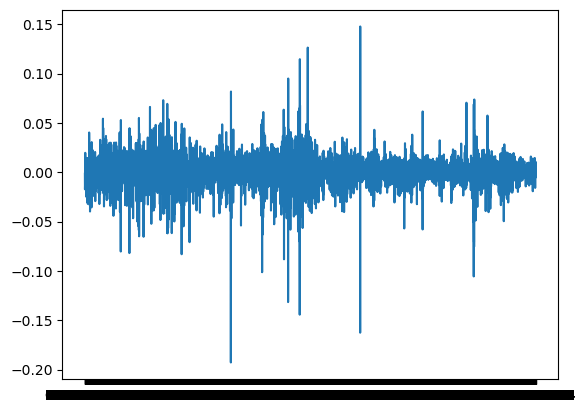

In [12]:
plt.plot(r_n50["Date"],r_n50["r_n50"] )

In [13]:
r_n50["Date"]

0       07-11-1994
1       08-11-1994
2       09-11-1994
3       10-11-1994
4       11-11-1994
           ...    
7291    21-03-2024
7292    22-03-2024
7293    26-03-2024
7294    27-03-2024
7295    28-03-2024
Name: Date, Length: 7296, dtype: object

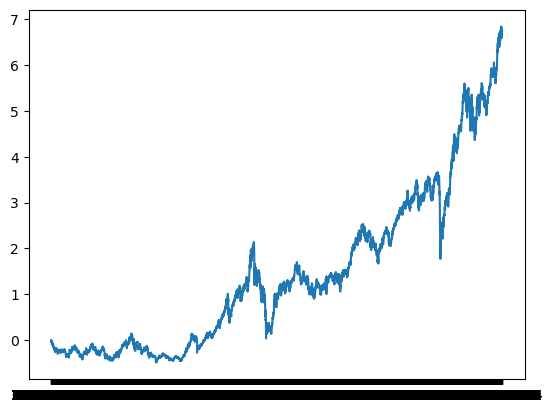

In [17]:
r_n50['cum_ret'] = (1 + r_n50["r_n50"]).cumprod() - 1 
plt.plot(r_n50["Date"],r_n50['cum_ret'] )

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 3.000e+00, 1.000e+00, 1.000e+00, 2.000e+00,
        1.000e+00, 3.000e+00, 7.000e+00, 6.000e+00, 5.000e+00, 8.000e+00,
        1.400e+01, 1.900e+01, 1.500e+01, 2.300e+01, 3.300e+01, 4.600e+01,
        6.400e+01, 8.400e+01, 1.160e+02, 1.890e+02, 2.620e+02, 4.040e+02,
        6.030e+02, 8.400e+02, 1.014e+03, 9.910e+02, 8.380e+02, 5.780e+02,
        3.760e+02, 2.470e+02, 1.620e+02, 1.120e+02, 4.800e+01, 4.500e+01,
        3.500e+01, 2.700e+01, 1.500e+01, 1.100e+01, 9.000e+00, 4.000e+00,
        6.000e+00, 1.000e+00, 3.000e+00, 2.000e+00, 4.000e+00, 2.000e+00,
        2.000e+00, 0.000e+00, 1.000e+0

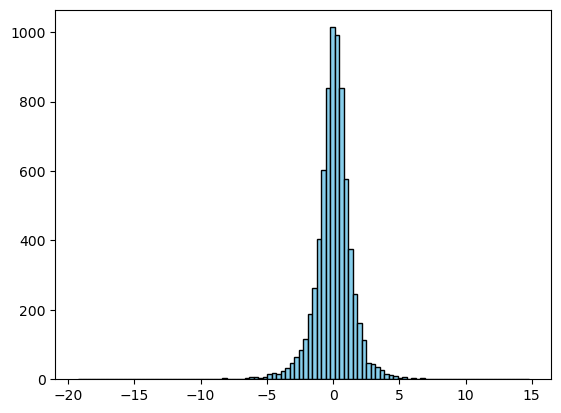

In [30]:
ret_n50_pct = r_n50["r_n50"]*100
#plot histogram
plt.hist(ret_n50_pct, bins=100, color='skyblue', edgecolor='black')

In [41]:
a= r_n50["r_n50"].quantile(0.10)
b = r_n50["r_n50"].quantile(0.05)
c= r_n50["r_n50"].quantile(0.0001)
a,b,c


(-0.014646933999999999, -0.0217034141, -0.17077564542839999)

In [39]:
a= r_n50["r_n50"].quantile(0.95)*100
b = r_n50["r_n50"].quantile(0.98999)*100
c= r_n50["r_n50"].quantile(0.9999999999)*100
a,b,c

(2.094684999999999, 3.717922672650005, 14.769454039677548)

In [42]:
df_target['pct_chg15'] = df_target['Close'].pct_change(15)
df_target['regime_change'] = df_target['pct_chg15'].rolling(window=5000, min_periods=2000).apply(lambda x:x[:-1].quantile(q=0.05)>x[-1])

NameError: name 'df_target' is not defined

In [45]:
window=10
data_vol = r_n50["r_n50"].rolling(window).std()


0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
7291    0.007567
7292    0.006608
7293    0.006716
7294    0.007005
7295    0.004826
Name: r_n50, Length: 7296, dtype: float64

In [49]:
pmin_pmax = (r_n50["r_n50"].diff(-1) > 0).astype(int).diff()
pmax = pmin_pmax[pmin_pmax == 1]
pmin = pmin_pmax[pmin_pmax == -1]

NameError: name 'data' is not defined

In [57]:
min_pmax = (price.diff(-1) > 0).astype(int).diff()
pmax = pmin_pmax[pmin_pmax == 1]
pmin = pmin_pmax[pmin_pmax == -1]
# make sure drawdowns start with pmax, end with pmin:
if pmin.index[0] < pmax.index[0]:
    pmin = pmin.drop(pmin.index[0])
if pmin.index[-1] < pmax.index[-1]:
    pmax = pmax.drop(pmax.index[-1])
D = (np.array(price[pmin.index]) - np.array(price\
     [pmax.index]))/ np.array(price[pmax.index])
d = {'Date':pmax.index, 'drawdown':D, 'd_start': pmax.index,\
     'd_end': pmin.index}    
df_d = pd.DataFrame(d).set_index('Date')
df_d.index = pd.to_datetime(df_d.index, format='%Y/%m/%d')
df_d = df_d.reindex(data.index).fillna(0)
df_d = df_d.sort_values(by='drawdown')
df_d['rank'] = list(range(1,df_d.shape[0]+1))
df_d = df_d.sort_values(by='Date')

#Jacobsson (99.5% quantile of drawdowns) 
ct = df_d[df_d['drawdown']<0]['drawdown'].quantile(1-0.995)
df_c = df_d[df_d['drawdown'] < ct]
df_c.columns = ['drawdown', 'crash_st', 'crash_end', 'rank']

ValueError: time data "9" doesn't match format "%Y/%m/%d", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [56]:
price=r_n50["Close"]
price

0        1283.0000
1        1281.0000
2        1259.0000
3        1241.0000
4        1223.0000
           ...    
7291    22011.9492
7292    22096.7500
7293    22004.6992
7294    22123.6504
7295    22326.9004
Name: Close, Length: 7296, dtype: float64